# Ising Model: Temperature Sweep and Critical Behavior

The two-dimensional Ising model is the simplest lattice system that still exhibits a genuine thermodynamic phase transition. Each site carries a spin $s_i \in \{+1,-1\}$ and neighbouring spins interact through $H = -J \sum_{\langle i,j \rangle} s_i s_j$. At low temperature the ferromagnetic coupling dominates and the lattice orders. At high temperature entropy wins, domains fragment, and the net magnetization disappears. In two dimensions the transition occurs at Onsager’s exact critical temperature $T_c = 2 / \ln(1 + \sqrt{2}) \approx 2.269$ [[1]](#Bibliography).

This notebook turns the Ising temperature-sweep workflow into a guided analysis. It first shows what ordered and disordered configurations look like, then tracks how the order parameter and the energy vary with temperature. The next sections focus on fluctuation observables, entropy, and the growth of autocorrelation near the transition. Every figure is tied either to the project cache at `results/ising/temperature_sweep_data.npz` or to a lightweight checkerboard-Metropolis fallback that uses the same observable definitions [[2]](#Bibliography) [[3]](#Bibliography).

In [15]:
from __future__ import annotations

from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

from models.ising_model import IsingSimulation
from utils.exceptions import ZeroVarianceAutocorrelationError
from utils.physics_helpers import (
    DEFAULT_CONFIDENCE_LEVEL,
    calculate_autocorr,
    summarize_derived_observable,
    summarize_entropy_observable,
    summarize_primary_observable,
)
from utils.system_helpers import convergence_equilibrate


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'results').exists():
            return candidate
    return cwd


REPO_ROOT = _find_repo_root()
TC_ISING = 2.0 / np.log(1.0 + np.sqrt(2.0))
CACHE_PATH = REPO_ROOT / 'results' / 'ising' / 'temperature_sweep_data.npz'
PALETTE = {
    'mag': '#4878CF',
    'eng': '#6ACC65',
    'chi': '#EE854A',
    'cv': '#D65F5F',
    'entropy': '#956CB4',
    'tau': '#8C613C',
}
SPIN_CMAP = mcolors.ListedColormap(['#4878CF', '#D65F5F'])

plt.rcParams['figure.dpi'] = 120

print(f'Exact Onsager T_c = {TC_ISING:.6f}')
print(f'Repository root: {REPO_ROOT}')
print(f'Primary sweep path: {CACHE_PATH}')

Exact Onsager T_c = 2.269185
Repository root: /workspaces/vibespin
Primary sweep path: /workspaces/vibespin/results/ising/temperature_sweep_data.npz


## Ordered and Disordered Configurations

A thermodynamic curve is easier to read when the underlying configurations are visible. The two panels below show equilibrated checkerboard-Metropolis configurations below and above $T_c$. Below the transition, most spins belong to one macroscopic domain and the lattice carries a large magnetization. Above the transition, thermal disorder breaks the system into short correlated patches. The figure is qualitative, but it shows the same change of regime that later appears in the temperature-dependent observables.

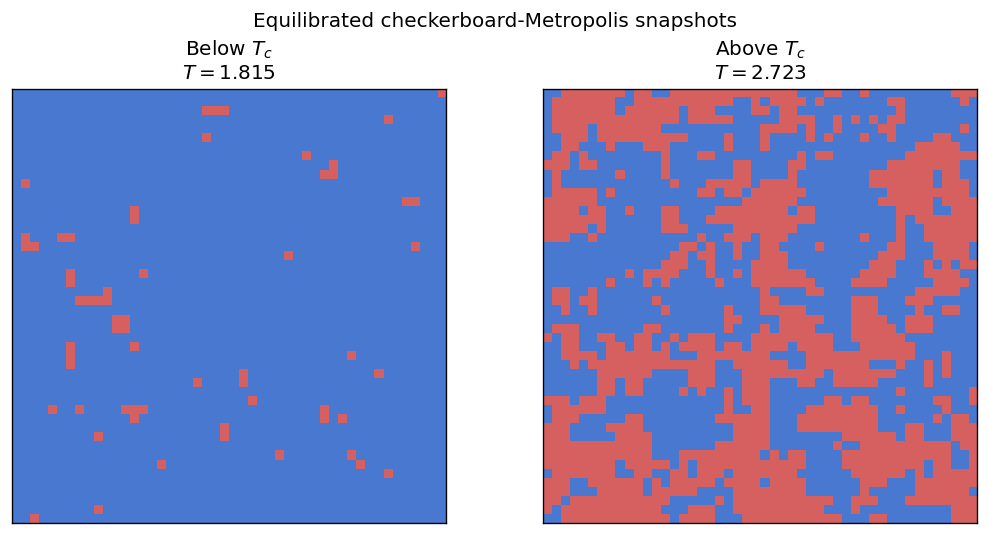

In [16]:
def _equilibrated_state(*, temp: float, size: int = 48, seed: int = 0) -> np.ndarray:
    sim_random = IsingSimulation(
        size=size,
        temp=temp,
        update='checkerboard',
        init_state='random',
        seed=seed,
    )
    sim_ordered = IsingSimulation(
        size=size,
        temp=temp,
        update='checkerboard',
        init_state='ordered',
        seed=seed,
    )
    convergence_equilibrate(
        sim_random,
        sim_ordered,
        chunk_size=120,
        max_steps=6000,
    )
    sim_random.run(n_steps=200)
    return np.array(sim_random.spins, copy=True)

snapshot_temperatures = [0.8 * TC_ISING, 1.2 * TC_ISING]
snapshot_titles = ['Below $T_c$', 'Above $T_c$']
snapshot_states = [
    _equilibrated_state(temp=float(temp), seed=200 + idx)
    for idx, temp in enumerate(snapshot_temperatures)
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, spins, title, temp in zip(axes, snapshot_states, snapshot_titles, snapshot_temperatures):
    ax.imshow(spins, cmap=SPIN_CMAP, vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(f'{title}\n$T = {temp:.3f}$')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Equilibrated checkerboard-Metropolis snapshots', y=0.98)
fig.tight_layout()
plt.show()

## Load or compute sweep data

The notebook first looks for the project cache at `results/ising/temperature_sweep_data.npz` by walking up to the repository root from the current working directory. If that file contains a sufficiently dense temperature grid, the plots are built from it directly. The repository currently also contains smoke-test outputs with only a couple of temperature points, which are not useful for a pedagogical sweep. In that case the notebook falls back to a compact in-notebook checkerboard-Metropolis calculation with two-start equilibration. The fallback is meant for explanation and validation rather than publication-quality estimates, but it keeps the narrative physically consistent because every later section still discusses local-update data [[4]](#Bibliography) [[5]](#Bibliography).

In [48]:
REQUIRED_KEYS = {
    'temperatures',
    'avg_m_value', 'avg_m_ci_low', 'avg_m_ci_high', 'avg_m_n_eff',
    'avg_e_value', 'avg_e_ci_low', 'avg_e_ci_high',
    'susc_value', 'susc_ci_low', 'susc_ci_high',
    'spec_h_value', 'spec_h_err', 'spec_h_ci_low', 'spec_h_ci_high',
    'tau_int', 'tau_int_ci_low', 'tau_int_ci_high',
    'undefined_autocorr_flag', 'tau_interval_unstable_flag',
}

fallback_meas_steps = 1200


def _run_local_sweep_point(
    *,
    temp: float,
    size: int,
    meas_steps: int,
    eq_probe_steps: int,
    eq_max_steps: int,
    seed: int,
) -> dict[str, float]:
    sim_random = IsingSimulation(
        size=size,
        temp=temp,
        update='checkerboard',
        init_state='random',
        seed=seed,
    )
    sim_ordered = IsingSimulation(
        size=size,
        temp=temp,
        update='checkerboard',
        init_state='ordered',
        seed=seed,
    )
    convergence_equilibrate(
        sim_random,
        sim_ordered,
        chunk_size=eq_probe_steps,
        max_steps=eq_max_steps,
    )

    mags, engs = sim_random.run(n_steps=meas_steps)
    mags_arr = np.asarray(mags, dtype=float)
    engs_arr = np.asarray(engs, dtype=float)

    mag = summarize_primary_observable(
        time_series=mags_arr,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )
    eng = summarize_primary_observable(
        time_series=engs_arr,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )
    chi = summarize_derived_observable(
        magnetization_series=mags_arr,
        temperature=temp,
        L=size,
        observable='chi',
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )
    cv = summarize_derived_observable(
        energy_series=engs_arr,
        temperature=temp,
        L=size,
        observable='cv',
        confidence=DEFAULT_CONFIDENCE_LEVEL,
    )

    return {
        'avg_m_value': float(mag['value']),
        'avg_m_ci_low': float(mag['ci_low']),
        'avg_m_ci_high': float(mag['ci_high']),
        'avg_m_n_eff': float(mag['n_eff']),
        'avg_e_value': float(eng['value']),
        'avg_e_ci_low': float(eng['ci_low']),
        'avg_e_ci_high': float(eng['ci_high']),
        'susc_value': float(chi['value']),
        'susc_ci_low': float(chi['ci_low']),
        'susc_ci_high': float(chi['ci_high']),
        'spec_h_value': float(cv['value']),
        'spec_h_err': float(cv['err']),
        'spec_h_ci_low': float(cv['ci_low']),
        'spec_h_ci_high': float(cv['ci_high']),
        'tau_int': float(mag['tau_int']),
        'tau_int_ci_low': float(mag['ci_low']) if not np.isfinite(mag['tau_int']) else float(max(0.0, mag['tau_int'] - mag['err'])),
        'tau_int_ci_high': float(mag['ci_high']) if not np.isfinite(mag['tau_int']) else float(mag['tau_int'] + mag['err']),
    }


cache_loaded = False
cache_reason = ''
requested_n_seeds = 1
retained_n_seeds = 1

if CACHE_PATH.exists():
    cache = np.load(CACHE_PATH)
    if REQUIRED_KEYS.issubset(set(cache.files)) and int(cache['temperatures'].size) >= 10:
        temperatures = np.asarray(cache['temperatures'], dtype=float)
        avg_m = np.asarray(cache['avg_m_value'], dtype=float)
        avg_m_ci_low = np.asarray(cache['avg_m_ci_low'], dtype=float)
        avg_m_ci_high = np.asarray(cache['avg_m_ci_high'], dtype=float)
        avg_m_n_eff = np.asarray(cache['avg_m_n_eff'], dtype=float)
        avg_e = np.asarray(cache['avg_e_value'], dtype=float)
        avg_e_ci_low = np.asarray(cache['avg_e_ci_low'], dtype=float)
        avg_e_ci_high = np.asarray(cache['avg_e_ci_high'], dtype=float)
        susc = np.asarray(cache['susc_value'], dtype=float)
        susc_ci_low = np.asarray(cache['susc_ci_low'], dtype=float)
        susc_ci_high = np.asarray(cache['susc_ci_high'], dtype=float)
        spec_h = np.asarray(cache['spec_h_value'], dtype=float)
        spec_h_err = np.asarray(cache['spec_h_err'], dtype=float)
        spec_h_ci_low = np.asarray(cache['spec_h_ci_low'], dtype=float)
        spec_h_ci_high = np.asarray(cache['spec_h_ci_high'], dtype=float)
        tau_int = np.asarray(cache['tau_int'], dtype=float)
        tau_int_ci_low = np.asarray(cache['tau_int_ci_low'], dtype=float)
        tau_int_ci_high = np.asarray(cache['tau_int_ci_high'], dtype=float)
        undefined_autocorr_flag = np.asarray(cache['undefined_autocorr_flag'], dtype=np.uint8)
        tau_interval_unstable_flag = np.asarray(cache['tau_interval_unstable_flag'], dtype=np.uint8)
        low_effective_sample_flag = (
            np.asarray(cache['low_effective_sample_flag'], dtype=np.uint8)
            if 'low_effective_sample_flag' in cache.files
            else np.zeros_like(temperatures, dtype=np.uint8)
        )
        entropy = (
            np.asarray(cache['entropy_value'], dtype=float)
            if 'entropy_value' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        entropy_ci_low = (
            np.asarray(cache['entropy_ci_low'], dtype=float)
            if 'entropy_ci_low' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        entropy_ci_high = (
            np.asarray(cache['entropy_ci_high'], dtype=float)
            if 'entropy_ci_high' in cache.files
            else np.asarray(cache['entropy'], dtype=float)
        )
        confidence_level = float(cache['confidence_level']) if 'confidence_level' in cache.files else DEFAULT_CONFIDENCE_LEVEL
        requested_n_seeds = int(cache['requested_n_seeds']) if 'requested_n_seeds' in cache.files else int(cache['n_seeds']) if 'n_seeds' in cache.files else 1
        retained_n_seeds = int(cache['retained_n_seeds']) if 'retained_n_seeds' in cache.files else int(cache['n_seeds']) if 'n_seeds' in cache.files else 1
        n_seeds = retained_n_seeds
        data_source = (
            f'Loaded cached sweep from {CACHE_PATH} '
            f'using {retained_n_seeds} retained seeds '
            f'out of {requested_n_seeds} requested.'
        )
        cache_loaded = True
    else:
        n_cached = int(cache['temperatures'].size) if 'temperatures' in cache.files else 0
        cache_reason = f'cache exists but only provides {n_cached} temperature points'
else:
    cache_reason = 'cache file not found'

if not cache_loaded:
    temperatures = np.linspace(1.4, 3.4, 15)
    avg_m = np.empty_like(temperatures)
    avg_m_ci_low = np.empty_like(temperatures)
    avg_m_ci_high = np.empty_like(temperatures)
    avg_m_n_eff = np.empty_like(temperatures)
    avg_e = np.empty_like(temperatures)
    avg_e_ci_low = np.empty_like(temperatures)
    avg_e_ci_high = np.empty_like(temperatures)
    susc = np.empty_like(temperatures)
    susc_ci_low = np.empty_like(temperatures)
    susc_ci_high = np.empty_like(temperatures)
    spec_h = np.empty_like(temperatures)
    spec_h_err = np.empty_like(temperatures)
    spec_h_ci_low = np.empty_like(temperatures)
    spec_h_ci_high = np.empty_like(temperatures)
    tau_int = np.empty_like(temperatures)
    tau_int_ci_low = np.empty_like(temperatures)
    tau_int_ci_high = np.empty_like(temperatures)
    spec_h_samples = np.empty((temperatures.size, 1), dtype=float)

    for idx, temp in enumerate(temperatures):
        point = _run_local_sweep_point(
            temp=float(temp),
            size=32,
            meas_steps=fallback_meas_steps,
            eq_probe_steps=150,
            eq_max_steps=12_000,
            seed=1_000 + idx,
        )
        avg_m[idx] = point['avg_m_value']
        avg_m_ci_low[idx] = point['avg_m_ci_low']
        avg_m_ci_high[idx] = point['avg_m_ci_high']
        avg_m_n_eff[idx] = point['avg_m_n_eff']
        avg_e[idx] = point['avg_e_value']
        avg_e_ci_low[idx] = point['avg_e_ci_low']
        avg_e_ci_high[idx] = point['avg_e_ci_high']
        susc[idx] = point['susc_value']
        susc_ci_low[idx] = point['susc_ci_low']
        susc_ci_high[idx] = point['susc_ci_high']
        spec_h[idx] = point['spec_h_value']
        spec_h_err[idx] = point['spec_h_err']
        spec_h_ci_low[idx] = point['spec_h_ci_low']
        spec_h_ci_high[idx] = point['spec_h_ci_high']
        tau_int[idx] = point['tau_int']
        tau_int_ci_low[idx] = point['tau_int_ci_low']
        tau_int_ci_high[idx] = point['tau_int_ci_high']
        spec_h_samples[idx, 0] = point['spec_h_value']

    entropy_bundle = summarize_entropy_observable(
        temperatures=temperatures,
        specific_heat_samples=spec_h_samples,
        specific_heat_err=spec_h_err,
        confidence=DEFAULT_CONFIDENCE_LEVEL,
        method='blocking',
    )
    entropy = np.asarray(entropy_bundle['value'], dtype=float)
    entropy_ci_low = np.asarray(entropy_bundle['ci_low'], dtype=float)
    entropy_ci_high = np.asarray(entropy_bundle['ci_high'], dtype=float)
    undefined_autocorr_flag = (~np.isfinite(tau_int)).astype(np.uint8)
    rel_width = (tau_int_ci_high - tau_int_ci_low) / np.maximum(np.abs(tau_int), 1e-12)
    tau_interval_unstable_flag = np.asarray(
        np.isfinite(rel_width) & (rel_width > 1.0),
        dtype=np.uint8,
    )
    low_effective_sample_flag = np.asarray(
        np.isfinite(avg_m_n_eff) & (avg_m_n_eff < 20.0),
        dtype=np.uint8,
    )
    confidence_level = DEFAULT_CONFIDENCE_LEVEL
    n_seeds = 1
    requested_n_seeds = 1
    retained_n_seeds = 1
    data_source = (
        'Computed a lightweight checkerboard-Metropolis fallback sweep '
        f'because {cache_reason}.'
    )

exclude_from_thermo_plots = undefined_autocorr_flag > 0

avg_m_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m)
avg_m_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m_ci_low)
avg_m_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, avg_m_ci_high)

avg_e_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e)
avg_e_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e_ci_low)
avg_e_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, avg_e_ci_high)

susc_plot = np.where(exclude_from_thermo_plots, np.nan, susc)
susc_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, susc_ci_low)
susc_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, susc_ci_high)

spec_h_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h)
spec_h_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h_ci_low)
spec_h_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, spec_h_ci_high)

entropy_plot = np.where(exclude_from_thermo_plots, np.nan, entropy)
entropy_ci_low_plot = np.where(exclude_from_thermo_plots, np.nan, entropy_ci_low)
entropy_ci_high_plot = np.where(exclude_from_thermo_plots, np.nan, entropy_ci_high)

print(data_source)
print(f'Temperature points: {temperatures.size}')
print(
    f'retained seeds = {retained_n_seeds} / requested seeds = {requested_n_seeds}, '
    f'confidence level = {confidence_level:.2f}'
)
print(f'Excluded points in thermodynamic plots: {int(np.sum(exclude_from_thermo_plots))}')

Loaded cached sweep from /workspaces/vibespin/results/ising/temperature_sweep_data.npz using 2 retained seeds out of 25 requested.
Temperature points: 39
retained seeds = 2 / requested seeds = 25, confidence level = 0.68
Excluded points in thermodynamic plots: 3


## Magnetization and Energy

The natural order parameter is the magnetization per spin. In a finite simulation the sign can flip after long runs, so VibeSpin records the absolute value $|M|$ rather than the signed magnetization. Below $T_c$ the curve stays close to one because almost all spins align. Above $T_c$ it falls toward zero because up and down states occur with comparable probability. The energy per spin moves more smoothly. It approaches the ordered ground-state limit near $-2J$ at low temperature and rises steadily as domain walls and thermal defects proliferate [[1]](#Bibliography) [[2]](#Bibliography).

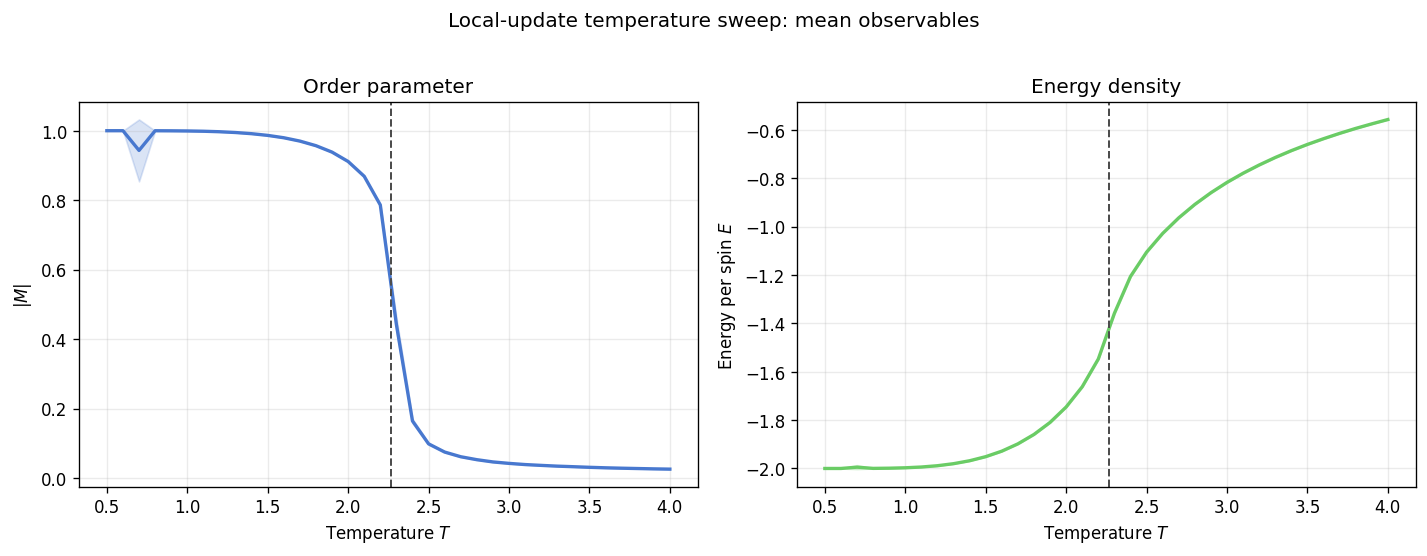

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, avg_m_plot, color=PALETTE['mag'], lw=2)
axes[0].fill_between(temperatures, avg_m_ci_low_plot, avg_m_ci_high_plot, color=PALETTE['mag'], alpha=0.2)
axes[0].axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'$|M|$')
axes[0].set_title('Order parameter')
axes[0].grid(alpha=0.25)

axes[1].plot(temperatures, avg_e_plot, color=PALETTE['eng'], lw=2)
axes[1].fill_between(temperatures, avg_e_ci_low_plot, avg_e_ci_high_plot, color=PALETTE['eng'], alpha=0.2)
axes[1].axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Energy per spin $E$')
axes[1].set_title('Energy density')
axes[1].grid(alpha=0.25)

fig.suptitle('Local-update temperature sweep: mean observables', y=1.02)
fig.tight_layout()
plt.show()

## Susceptibility and Specific Heat

The order-parameter curve identifies the transition window, but the fluctuation observables make that window much sharper. The susceptibility $\chi = N\,\mathrm{Var}(|M|)/T$ measures how strongly the magnetization responds to thermal noise, while the specific heat $C_v = N\,\mathrm{Var}(E)/T^2$ measures energy fluctuations. Both quantities peak in the critical regime because the lattice samples many competing domain structures there. For a finite lattice these are rounded maxima rather than true singularities, but they are the finite-size precursors of the exact Ising critical behaviour [[1]](#Bibliography) [[2]](#Bibliography).

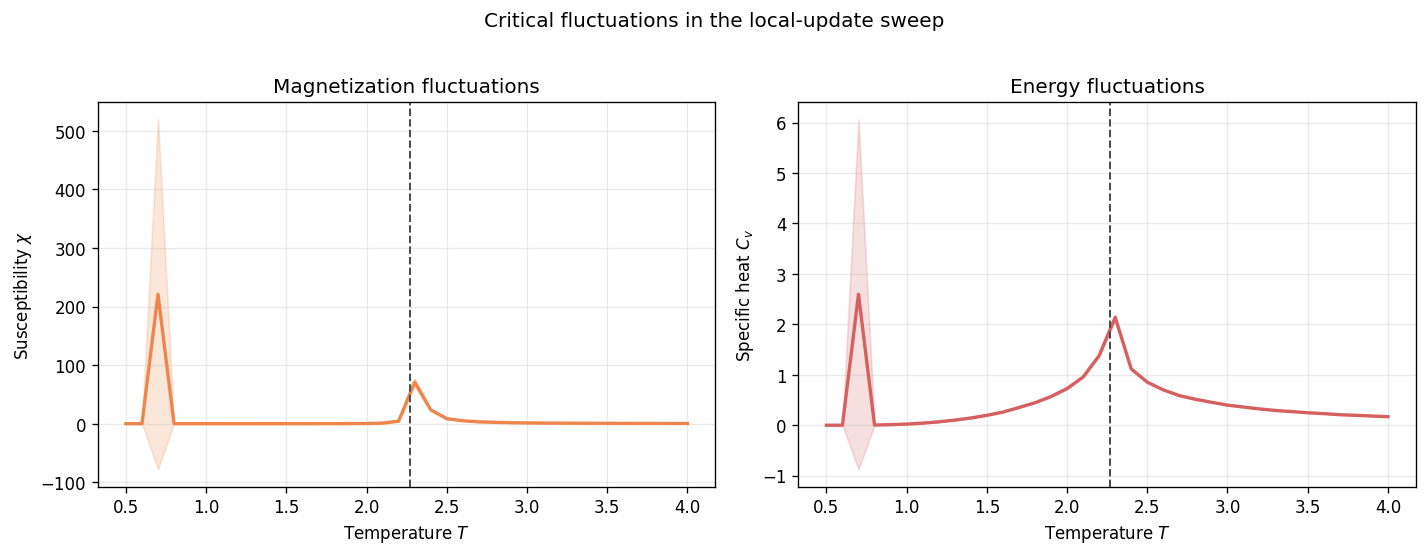

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, susc_plot, color=PALETTE['chi'], lw=2)
axes[0].fill_between(temperatures, susc_ci_low_plot, susc_ci_high_plot, color=PALETTE['chi'], alpha=0.2)
axes[0].axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'Susceptibility $\chi$')
axes[0].set_title('Magnetization fluctuations')
axes[0].grid(alpha=0.25)

axes[1].plot(temperatures, spec_h_plot, color=PALETTE['cv'], lw=2)
axes[1].fill_between(temperatures, spec_h_ci_low_plot, spec_h_ci_high_plot, color=PALETTE['cv'], alpha=0.2)
axes[1].axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Specific heat $C_v$')
axes[1].set_title('Energy fluctuations')
axes[1].grid(alpha=0.25)

fig.suptitle('Critical fluctuations in the local-update sweep', y=1.02)
fig.tight_layout()
plt.show()

## Entropy

The sweep also carries enough information to reconstruct an entropy curve from the specific heat. In this notebook the entropy is shown with the same convention used by the helper functions: the highest sampled temperature is the reference point, so the plotted curve is relative rather than absolutely normalised. That choice changes only an additive constant. The shape still shows where configurational disorder builds up most rapidly, and that happens in the same temperature window where $C_v$ is largest. If one wants the absolute high-temperature entropy of the Ising model, the whole curve would simply be shifted by approximately $\ln 2$ per spin [[2]](#Bibliography).

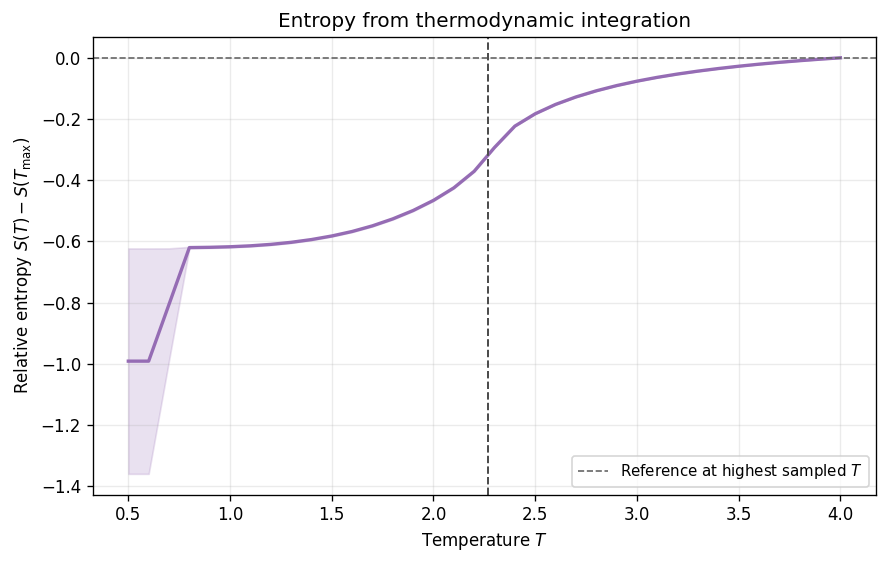

In [51]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(temperatures, entropy_plot, color=PALETTE['entropy'], lw=2)
ax.fill_between(temperatures, entropy_ci_low_plot, entropy_ci_high_plot, color=PALETTE['entropy'], alpha=0.2)
ax.axhline(0.0, color='0.4', ls='--', lw=1.0, label=r'Reference at highest sampled $T$')
ax.axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
ax.set_xlabel('Temperature $T$')
ax.set_ylabel(r'Relative entropy $S(T) - S(T_{\max})$')
ax.set_title('Entropy from thermodynamic integration')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Critical Slowing Down

Thermodynamic signatures and numerical cost peak in the same region. The integrated autocorrelation time $\tau_{\mathrm{int}}$ measures how long the checkerboard-Metropolis Markov chain remembers a magnetization fluctuation once the system is already in equilibrium. The effective sample size behaves roughly as $N_{\mathrm{eff}} \sim N_{\mathrm{meas}} / (2\tau_{\mathrm{int}})$, so a large autocorrelation time means that many recorded steps contain little new information. Near $T_c$ the correlation length grows, collective spin rearrangements become slow, and local updates decorrelate inefficiently. That is the local-update version of critical slowing down discussed by Madras, Sokal, and Newman-Barkema [[4]](#Bibliography) [[5]](#Bibliography) [[6]](#Bibliography).

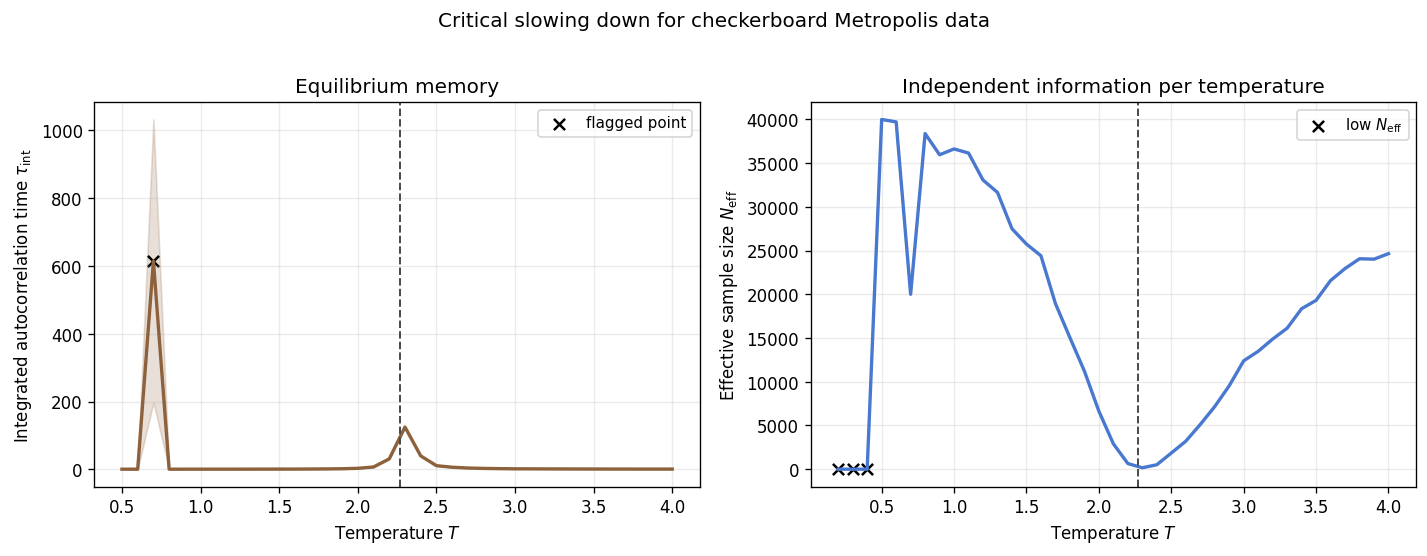

In [52]:
flagged_tau = (undefined_autocorr_flag > 0) | (tau_interval_unstable_flag > 0)
flagged_neff = low_effective_sample_flag > 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(temperatures, tau_int, color=PALETTE['tau'], lw=2)
axes[0].fill_between(temperatures, tau_int_ci_low, tau_int_ci_high, color=PALETTE['tau'], alpha=0.2)
axes[0].axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
if np.any(flagged_tau):
    axes[0].scatter(
        temperatures[flagged_tau],
        tau_int[flagged_tau],
        color='black',
        marker='x',
        s=45,
        label='flagged point',
    )
axes[0].set_xlabel('Temperature $T$')
axes[0].set_ylabel(r'Integrated autocorrelation time $\tau_{\mathrm{int}}$')
axes[0].set_title('Equilibrium memory')
axes[0].grid(alpha=0.25)
if np.any(flagged_tau):
    axes[0].legend(fontsize=9)

axes[1].plot(temperatures, avg_m_n_eff, color=PALETTE['mag'], lw=2)
axes[1].axvline(TC_ISING, color='0.3', ls='--', lw=1.2)
if np.any(flagged_neff):
    axes[1].scatter(
        temperatures[flagged_neff],
        avg_m_n_eff[flagged_neff],
        color='black',
        marker='x',
        s=45,
        label=r'low $N_{\mathrm{eff}}$',
    )
axes[1].set_xlabel('Temperature $T$')
axes[1].set_ylabel(r'Effective sample size $N_{\mathrm{eff}}$')
axes[1].set_title('Independent information per temperature')
axes[1].grid(alpha=0.25)
if np.any(flagged_neff):
    axes[1].legend(fontsize=9)

fig.suptitle('Critical slowing down for checkerboard Metropolis data', y=1.02)
fig.tight_layout()
plt.show()

## Autocorrelation Function at Three Temperatures

The previous figure compresses equilibrium memory into a single number at each temperature. The next plot shows the underlying autocorrelation function $\rho_M(\tau)$ itself for checkerboard-Metropolis trajectories below, near, and above $T_c$. Away from the transition the correlation drops quickly because the simulation explores independent local rearrangements after only a short lag. Close to $T_c$ the decay is much slower, so the area under $\rho_M(\tau)$ becomes large and the integrated autocorrelation time grows with it [[4]](#Bibliography) [[5]](#Bibliography).

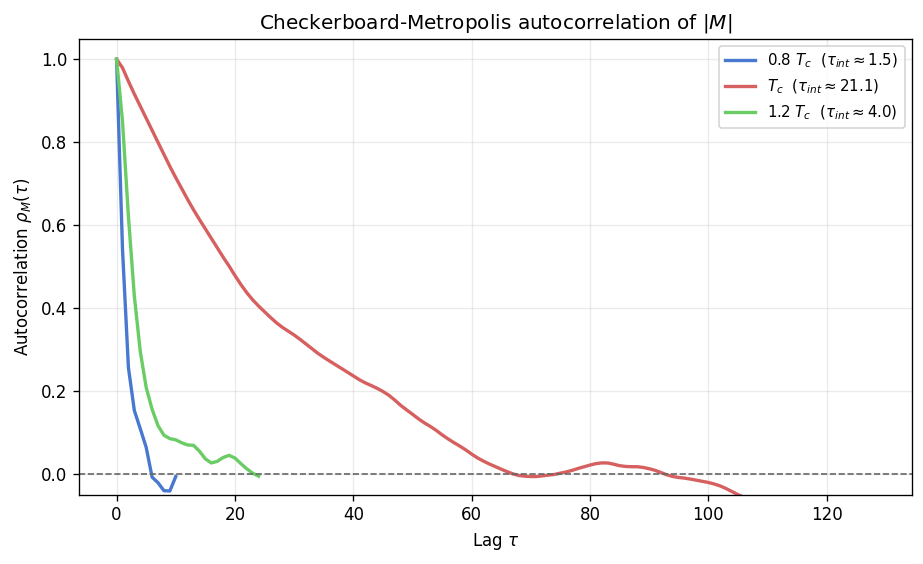

In [53]:
autocorr_temperatures = [0.8 * TC_ISING, TC_ISING, 1.2 * TC_ISING]
autocorr_labels = ['0.8 $T_c$', '$T_c$', '1.2 $T_c$']
autocorr_colors = ['#4878CF', '#D65F5F', '#6ACC65']

fig, ax = plt.subplots(figsize=(7.8, 4.8))

for idx, (temp, label, color) in enumerate(zip(autocorr_temperatures, autocorr_labels, autocorr_colors)):
    sim_random = IsingSimulation(
        size=40,
        temp=float(temp),
        update='checkerboard',
        init_state='random',
        seed=5_000 + idx,
    )
    sim_ordered = IsingSimulation(
        size=40,
        temp=float(temp),
        update='checkerboard',
        init_state='ordered',
        seed=5_000 + idx,
    )
    convergence_equilibrate(
        sim_random,
        sim_ordered,
        chunk_size=120,
        max_steps=9_000,
    )
    mags, _ = sim_random.run(n_steps=1_600)
    mags_arr = np.asarray(mags, dtype=float)
    try:
        corr, tau_here = calculate_autocorr(time_series=mags_arr, max_lag=160)
    except ZeroVarianceAutocorrelationError:
        corr = np.array([np.nan])
        tau_here = float('nan')
    lags = np.arange(corr.size)
    ax.plot(lags, corr, lw=2, color=color, label=f'{label}  ($\\tau_{{int}} \\approx {tau_here:.1f}$)')

ax.axhline(0.0, color='0.4', ls='--', lw=1.0)
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'Autocorrelation $\rho_M(\tau)$')
ax.set_title(r'Checkerboard-Metropolis autocorrelation of $|M|$')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## Synthesis

The notebook now shows the same transition from several angles. The order parameter falls, the energy curve bends, the susceptibility and specific heat develop maxima, the entropy changes slope most rapidly, and the autocorrelation time reaches its largest values in the same narrow temperature window. These are not separate phenomena. They all come from the growth of long-range critical fluctuations. The same correlated domains that make the equilibrium state highly susceptible also make local Monte Carlo dynamics slow.

For equilibrium work near $T_c$, this is exactly where cluster updates become valuable. The companion notebooks on Wolff efficiency, relaxation, and dynamical critical exponents explain how nonlocal updates suppress the local decorrelation bottleneck without changing the equilibrium Boltzmann distribution. This notebook stays with the local temperature sweep so that the thermodynamic story and the sampling-cost story are told with one consistent dataset.

## Bibliography

[[1]](#Bibliography) L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review* 65, 117-149 (1944). [APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[[2]](#Bibliography) K. Huang, *Statistical Mechanics*, 2nd edition, Wiley (1987). [Open lecture notes by John Cardy](https://arxiv.org/pdf/0807.3472.pdf)

[[3]](#Bibliography) W. K. Hastings, "Monte Carlo sampling methods using Markov chains and their applications," *Biometrika* 57, 97-109 (1970). [Oxford Academic](https://academic.oup.com/biomet/article/57/1/97/252073)

[[4]](#Bibliography) G. S. Madras and A. D. Sokal, "The pivot algorithm: A highly efficient Monte Carlo method for the self-avoiding walk," *Journal of Statistical Physics* 50, 109-186 (1988). [Springer Open Access](https://link.springer.com/article/10.1007/BF01022990)

[[5]](#Bibliography) A. D. Sokal, "Monte Carlo Methods in Statistical Mechanics: Foundations and New Algorithms," lecture notes (1989), reprinted in *Functional Integration: Basics and Applications* (1997). [Springer Link](https://link.springer.com/chapter/10.1007/978-1-4899-0319-8_6)

[[6]](#Bibliography) M. E. J. Newman and G. T. Barkema, *Monte Carlo Methods in Statistical Physics*, Oxford University Press (1999). [Lecture notes summary](https://arxiv.org/abs/0905.1629)